# 06 - Document AI / Document Understanding

This notebook demonstrates the document-processing side of the platform using
`invoice_demo.png`. In demo mode the project now returns a real `DocumentResult`
with fields, tables, full text, and page count.


## Setup

In [1]:
# !pip install oci-vision-ai[notebooks]

from oci_vision.core.client import VisionClient

client = VisionClient(demo=True)
print(f"Client ready (demo={client.is_demo})")

Client ready (demo=True)


## Run the analysis

`analyze_document()` normalizes the OCI document response into a compact
`DocumentResult`. The demo fixture exercises field extraction, table extraction,
and text flattening.


In [2]:
result = client.analyze_document("invoice_demo.png")
print(f"Model version: {result.model_version}")
print(f"Pages: {result.page_count}")
print(f"Fields: {len(result.fields)}")
print(f"Tables: {len(result.tables)}")
print()
print(result.full_text)

Model version: 1.0.0
Pages: 1
Fields: 2
Tables: 1

INVOICE
Invoice Number: INV-1001


## Explore the results

The normalized `DocumentResult` keeps the API friendly: key-value fields,
simplified tables, full text, and page count.


In [3]:
from oci_vision.core.models import DocumentField, DocumentResult, DocumentTable

print(type(result).__name__)
print("Field labels:", [field.label for field in result.fields])
print("Table headers:", [table.header_rows for table in result.tables])

DocumentResult
Field labels: ['Invoice Number', 'Total Due']
Table headers: [['Item', 'Qty', 'Price']]


### Extracted fields (key-value pairs)

In [4]:
# Display extracted fields
print(f"{'Field':20s}  {'Value':20s}  {'Confidence':>10s}")
print('-' * 60)
for field in result.fields:
    print(f"{field.label:20s}  {field.value:20s}  {field.confidence:9.2%}")

Field                 Value                 Confidence
------------------------------------------------------------
Invoice Number        INV-1001                 97.00%
Total Due             $10.00                   96.00%


### Extracted tables

In [5]:
# Display tables
for t_idx, table in enumerate(result.tables, 1):
    print(f"Table {t_idx}: {table.row_count} rows x {table.column_count} cols (confidence: {table.confidence:.1%})")
    print()
    header = table.header_rows
    print(f"  {'  '.join(f'{h:>12s}' for h in header)}")
    print(f"  {'  '.join('-' * 12 for _ in header)}")
    for row in table.body_rows:
        print(f"  {'  '.join(f'{c:>12s}' for c in row)}")

Table 1: 2 rows x 3 cols (confidence: 96.0%)

          Item           Qty         Price
  ------------  ------------  ------------
        Widget             2        $10.00


### Convert to pandas DataFrame

In [6]:
import pandas as pd

fields_df = pd.DataFrame([
    {"Field": f.label, "Value": f.value, "Confidence": f"{f.confidence:.1%}"}
    for f in result.fields
])
print("Key-Value Pairs:")
print(fields_df.to_string(index=False))
print()

for t_idx, table in enumerate(result.tables, 1):
    table_df = pd.DataFrame(table.body_rows, columns=table.header_rows)
    print(f"Table {t_idx}:")
    print(table_df.to_string(index=False))

Key-Value Pairs:
         Field    Value Confidence
Invoice Number INV-1001      97.0%
     Total Due   $10.00      96.0%

Table 1:
  Item Qty  Price
Widget   2 $10.00


## Visualize

The project's current renderer focuses on image, OCR, and face overlays. For
documents, a useful first visualization is the source image plus confidence by
extracted field.


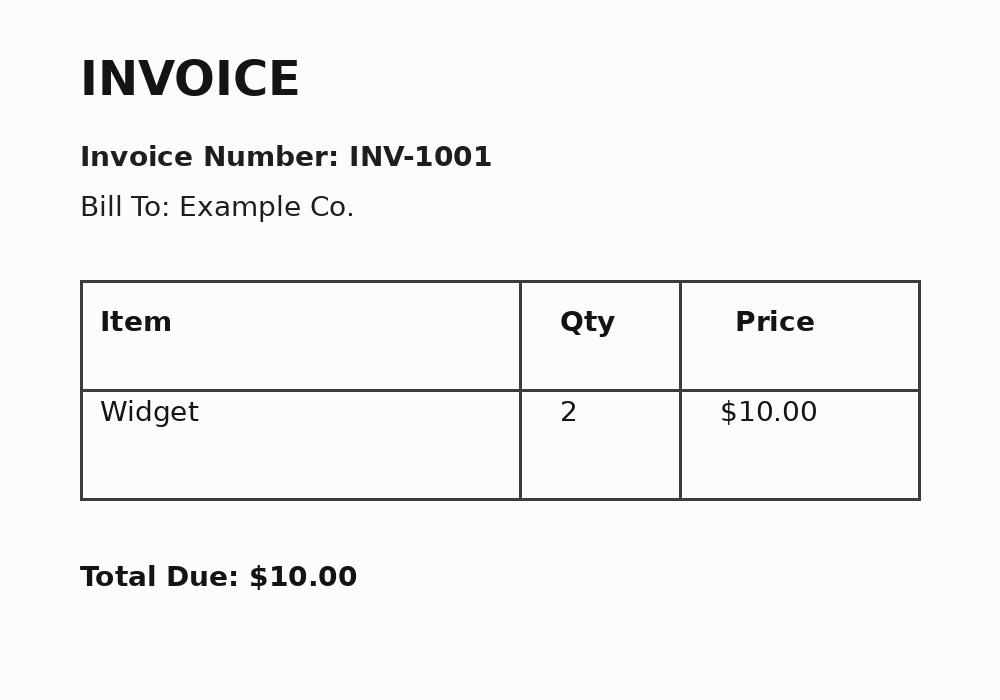

In [7]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from PIL import Image
from oci_vision.gallery import get_gallery_path

image_path = get_gallery_path() / 'images' / 'invoice_demo.png'
invoice_image = Image.open(image_path)
display(invoice_image)

labels = [f.label for f in result.fields]
confs = [f.confidence * 100 for f in result.fields]

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(labels, confs, color='#2A9D8F')
ax.set_xlabel('Confidence (%)')
ax.set_title('Invoice Field Extraction Confidence')
ax.set_xlim(0, 105)
for i, conf in enumerate(confs):
    ax.text(conf + 0.5, i, f'{conf:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

## Under the hood

In [8]:
import json

raw = result.model_dump()
print(json.dumps(raw, indent=2, default=str))

{
  "model_version": "1.0.0",
  "fields": [
    {
      "field_type": "KEY_VALUE",
      "label": "Invoice Number",
      "value": "INV-1001",
      "confidence": 0.97
    },
    {
      "field_type": "KEY_VALUE",
      "label": "Total Due",
      "value": "$10.00",
      "confidence": 0.96
    }
  ],
  "tables": [
    {
      "row_count": 2,
      "column_count": 3,
      "header_rows": [
        "Item",
        "Qty",
        "Price"
      ],
      "body_rows": [
        [
          "Widget",
          "2",
          "$10.00"
        ]
      ],
      "confidence": 0.96
    }
  ],
  "full_text": "INVOICE\nInvoice Number: INV-1001",
  "page_count": 1
}


### Live API usage

In Oracle's current product naming, document extraction lives under Document
Understanding. The Python client surface here stays simple:

```python
client = VisionClient()
result = client.analyze_document("invoice.pdf")
```

From there, `result.fields`, `result.tables`, `result.full_text`, and
`result.page_count` are ready for downstream processing.


## Try it yourself

1. Swap in a live invoice, receipt, or form.
2. Convert `result.tables` into pandas DataFrames for analysis.
3. Record a new document fixture with `oci-vision record-demo`.
4. Compare extracted output with `oci-vision eval document pred.json truth.json`.
